





























### Ładowanie danych

In [1]:
import sys, json, subprocess
from pathlib import Path

import json
import re

import seaborn as sns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
DATA_PATH    = PROJECT_ROOT / 'outputs' / 'single-cell-tracks_exp1-6_noErbB2.csv'
META_PATH    = PROJECT_ROOT / 'outputs' / '01-readme-experiment-description_2022-04-05.csv'
OUTPUT_ROOT  = PROJECT_ROOT / 'outputs'

EXP_ID     = 1
SITE_ID    = 1
SIGNAL_COL = 'ERKKTR_ratio'

def run_block(exp, site, signal, radius, window, quantile, threshold=None):
    """Run the single-block script and return the parsed summary dict."""
    tag   = f'exp_{exp}_site_{site}_{signal}_r{radius}_w{window}_q{int(quantile*100)}'
    outdir = OUTPUT_ROOT / tag
    cmd = [
        sys.executable,
        str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
        '--data-path',            str(DATA_PATH),
        '--meta-path',            str(META_PATH),
        '--exp-id',               str(exp),
        '--site-id',              str(site),
        '--signal-col',           signal,
        '--spatial-radius',       str(radius),
        '--future-window-frames', str(window),
        '--jump-quantile',        str(quantile),
        '--output-dir',           str(outdir.parent),
    ]
    if threshold is not None:
        cmd += ['--jump-threshold', str(threshold)]
    subprocess.run(cmd, capture_output=True)
    summary_path = outdir / 'summary.json'
    if not summary_path.exists():
        # fallback: script may have used default output naming
        summary_path = OUTPUT_ROOT / f'exp_{exp}_site_{site}_{signal}' / 'summary.json'
    with open(summary_path) as f:
        return json.load(f)

print('Setup complete.')

Setup complete.


In [ ]:
radii = range(15,200,15) # for a more informative plot
rows_r = []
for r in radii:
    print(f'  running r={r} …', end=' ', flush=True)
    outdir = OUTPUT_ROOT / f'sweep_r{r}'
    cmd = [
        sys.executable, str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
        '--data-path', str(DATA_PATH), '--meta-path', str(META_PATH),
        '--exp-id', str(EXP_ID), '--site-id', str(SITE_ID),
        '--signal-col', SIGNAL_COL,
        '--spatial-radius', str(r),
        '--future-window-frames', '3',
        '--jump-quantile', '0.9',
        '--output-dir', str(outdir),
    ]
    subprocess.run(cmd, capture_output=True)
    sp = next((outdir / f'exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}').glob('summary.json'), None)
    if sp is None:
        sp = outdir / f'exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}' / 'summary.json'
    with open(sp) as f:
        s = json.load(f)
    rows_r.append({
        'r': r,
        '|E_sp|': s['n_spatial_edges'],
        'θ': round(s['jump_threshold'], 4),
        'p_exp': round(s['future_jump_rate_if_neighbor_jumps_now'], 4),
        'p_unexp': round(s['future_jump_rate_if_no_neighbor_jumps_now'], 4),
        'RR': round(s['relative_risk'], 4),
        'RD': round(s['risk_difference'], 4),
    })
    print('done')

df_r = pd.DataFrame(rows_r).set_index('r')

  running r=60 … done


In [2]:
summary_files = sorted(OUTPUT_ROOT.glob('sweep_r*/exp_1_site_1_ERKKTR_ratio/summary.json'))

rows=[]
for file in summary_files:
    with open(file) as f:
        data = json.load(f)

    # ekstrakcja promienia z nazwy katalogu
    m = re.search(r"sweep_r(\d+)", str(file))
    data["spatial_radius"] = int(m.group(1)) if m else None

    rows.append(data)

df = pd.DataFrame(rows).sort_values("spatial_radius")


### wizualizacja

<>:23: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:23: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_10651/2973159935.py:23: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.xlabel("Spatial Radius $r$ ($\mu m$ or pixels)", fontsize=11)


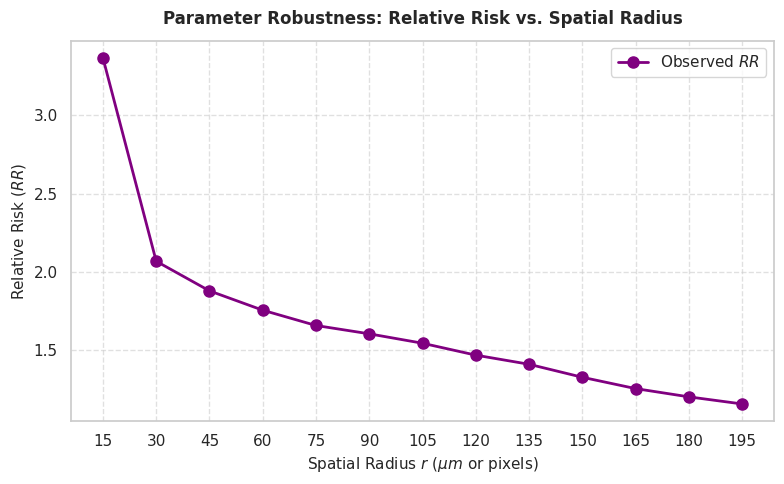

In [4]:
# 3. Generowanie wykresu Robustness Assessment
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Rysujemy linię z punktami (line + scatter)
plt.plot(
    df["spatial_radius"],
    df["relative_risk"],
    marker="o",
    linewidth=2,
    color="purple",
    markersize=8,
    label="Observed $RR$",
)

# Stylizacja wykresu
plt.title(
    "Parameter Robustness: Relative Risk vs. Spatial Radius",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
plt.xlabel("Spatial Radius $r$ ($\mu m$ or pixels)", fontsize=11)
plt.ylabel("Relative Risk ($RR$)", fontsize=11)
plt.xticks(df["spatial_radius"].unique())
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

import os
os.makedirs(PROJECT_ROOT / 'outputs', exist_ok=True)
plt.savefig(PROJECT_ROOT / 'outputs' / 'parameter_robustness.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

### Interpretacja

Relatywne ryzyko jest odwrotnie proporcjonalne do "Spatial Radius", im bliżej komórka jest drugiej komórki - tym bardziej ryzyko rośnie. 

RR gwałtownie spada między 15 a 30, po czym zaczyna łagodnie opadać, co wskazuje na istotność tego parametru.
Dla wartości niskich (15-30) zbyt bardzo zawężamy ilość sąsiadujących komórek co może wprowadzić szum stochastyczny. Natomiast dla wartości wysokich (od 75) wprowadzamy dużo komórek znacznie oddalonych, co powoduje efekt rozcieńczenia - nieisitone komórki zaczynają dominować dane. Należy odnaleźć "złoty środek" - wartości 45-60.
